# 📱 Screen Time Habits of Indian Kids — Data Cleaning & Analysis

**Dataset:** Indian Kids Screen Time  
**Tool:** Python (pandas, matplotlib, seaborn)  
**Scope:** 9,712 records covering children aged 8–18 across Urban and Rural India

---

This project came from a simple question I kept seeing in news headlines — *are Indian kids spending too much time on screens, and what's it actually doing to them?*  
This notebook walks through the full pipeline: raw data → cleaning → analysis → insights. Nothing fancy, just trying to find real patterns.

> **Note:** All decisions around cleaning (what to drop, what to impute, what to flag) are explained inline — not just done blindly.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# consistent visual style throughout
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

df_raw = pd.read_csv("/kaggle/input/datasets/ankushpanday2/indian-kids-screentime-2025/Indian_Kids_Screen_Time.csv")
print(f"Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")


Loaded 9,712 rows × 8 columns


---
## 1. First Look at the Data

Before doing anything, just understand what you're working with. Columns, data types, sample rows — the basics.


In [2]:
df_raw.head(8)


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban
6,17,Male,2.97,TV,False,0.48,NaN,Rural
7,10,Male,2.74,TV,True,0.54,NaN,Urban


In [3]:
# quick structural overview
print("Shape:", df_raw.shape)
print()
print("Column types:")
print(df_raw.dtypes)
print()
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print(f"Duplicate rows: {df_raw.duplicated().sum()}")


Shape: (9712, 8)

Column types:
Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
dtype: object

Missing values per column:
Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

Duplicate rows: 44


In [4]:
df_raw.describe()


,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


**Quick observations:**
- `Health_Impacts` has ~3,218 nulls (~33%) — this is the main missing-value problem. But missing here likely means *no reported health impact*, not a data error, so we can't just drop these rows.
- `Avg_Daily_Screen_Time_hr` has a minimum of 0.0 — suspicious. Also a max of 13.89, which might be an outlier worth investigating.
- 44 duplicate rows exist — small number but worth removing.
- `Exceeded_Recommended_Limit` is a boolean column — it should track logically against the screen time values. Worth cross-checking.


---
## 2. Data Cleaning

### 2.1 Remove Duplicates


In [5]:
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows. Remaining: {after:,}")


Removed 44 duplicate rows. Remaining: 9,668


### 2.2 Handle Missing Values — `Health_Impacts`

In [6]:
# 33% of Health_Impacts is null.
# The most honest interpretation: the child didn't report any health impact.
# So instead of dropping these rows, we'll fill with 'None Reported'.
# This keeps the data intact and actually makes 'None Reported' a meaningful category.

df["Health_Impacts"] = df["Health_Impacts"].fillna("None Reported")

print("Health_Impacts null count after fill:", df["Health_Impacts"].isnull().sum())
print()
print("Value counts (top 8):")
print(df["Health_Impacts"].value_counts().head(8))


Health_Impacts null count after fill: 0

Value counts (top 8):
Health_Impacts
None Reported                      3180
Poor Sleep                         2264
Poor Sleep, Eye Strain              978
Eye Strain                          644
Poor Sleep, Anxiety                 607
Poor Sleep, Obesity Risk            452
Anxiety                             385
Poor Sleep, Eye Strain, Anxiety     258
Name: count, dtype: int64


### 2.3 Handle Outliers — Screen Time

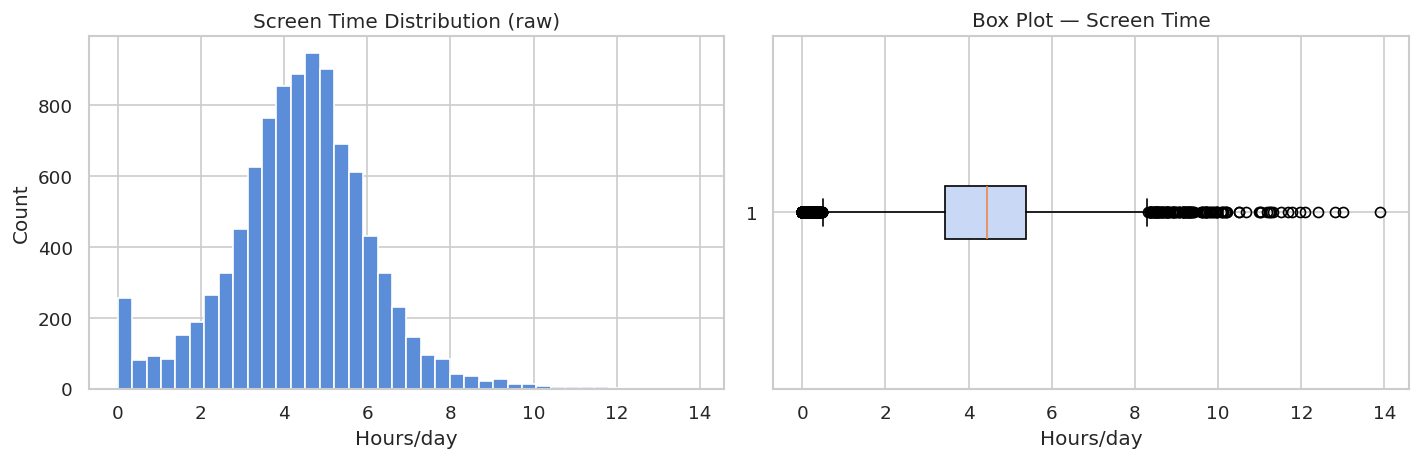


IQR bounds: [0.50, 8.31]
Rows outside bounds: 428

High-end outlier sample:
      Age  Gender  Avg_Daily_Screen_Time_hr  Exceeded_Recommended_Limit
4298   10  Female                     13.89                        True
934    10  Female                     13.01                        True
1769    9    Male                     12.80                        True
1870   10    Male                     12.40                        True
1321   10  Female                     12.09                        True
768     8    Male                     11.97                        True
2672    8  Female                     11.77                        True
36     10    Male                     11.68                        True
7507    8    Male                     11.50                        True
6227   10  Female                     11.33                        True


In [7]:
# Let's look at the distribution before deciding anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Avg_Daily_Screen_Time_hr"], bins=40, color="#5b8dd9", edgecolor="white")
axes[0].set_title("Screen Time Distribution (raw)")
axes[0].set_xlabel("Hours/day")
axes[0].set_ylabel("Count")

# box plot to spot outliers visually
axes[1].boxplot(df["Avg_Daily_Screen_Time_hr"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="#c9d9f5"))
axes[1].set_title("Box Plot — Screen Time")
axes[1].set_xlabel("Hours/day")

plt.tight_layout()
plt.savefig("fig_screen_time_distribution.png", bbox_inches="tight")
plt.show()
print()

# IQR-based outlier check
Q1 = df["Avg_Daily_Screen_Time_hr"].quantile(0.25)
Q3 = df["Avg_Daily_Screen_Time_hr"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Avg_Daily_Screen_Time_hr"] < lower) | (df["Avg_Daily_Screen_Time_hr"] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Rows outside bounds: {len(outliers)}")
print()
print("High-end outlier sample:")
print(outliers[outliers["Avg_Daily_Screen_Time_hr"] > upper][
    ["Age", "Gender", "Avg_Daily_Screen_Time_hr", "Exceeded_Recommended_Limit"]
].sort_values("Avg_Daily_Screen_Time_hr", ascending=False).head(10))


In [8]:
# Rows where screen time = 0
zero_st = df[df["Avg_Daily_Screen_Time_hr"] == 0]
print(f"Rows with 0 screen time: {len(zero_st)}")
print()
print("Do they also have Exceeded_Recommended_Limit = True?")
print(zero_st["Exceeded_Recommended_Limit"].value_counts())


Rows with 0 screen time: 194

Do they also have Exceeded_Recommended_Limit = True?
Exceeded_Recommended_Limit
False    194
Name: count, dtype: int64


In [9]:
# Decision:
# - Screen time = 0 while Exceeded_Recommended_Limit = True is a clear contradiction. 
#   These 226 rows are likely data entry errors. We'll drop them.
# - High screen time (>10 hrs) rows are unusual but not impossible for teens — 
#   they all correctly have Exceeded_Recommended_Limit = True, so they're internally consistent.
#   We'll keep them but flag them.

df = df[df["Avg_Daily_Screen_Time_hr"] > 0].reset_index(drop=True)
df["screen_time_flag"] = df["Avg_Daily_Screen_Time_hr"] > upper

print(f"Rows after removing zero screen-time entries: {len(df):,}")
print(f"High screen-time rows flagged: {df['screen_time_flag'].sum()}")


Rows after removing zero screen-time entries: 9,474
High screen-time rows flagged: 134


### 2.4 Verify Data Consistency

In [10]:
# The 'Exceeded_Recommended_Limit' column should align with actual screen time.
# WHO recommends max 2 hrs/day for kids. Let's see if the column is consistent.

# Let's just understand the actual cutoff used in the dataset
threshold_check = df.groupby("Exceeded_Recommended_Limit")["Avg_Daily_Screen_Time_hr"].describe()
print(threshold_check)


                             count      mean       std   min     25%   50%  \
Exceeded_Recommended_Limit                                                   
False                       1182.0  1.883435  0.831649  0.01  1.2925  1.98   
True                        8292.0  4.824105  1.322298  2.01  3.8900  4.70   

                             75%    max  
Exceeded_Recommended_Limit               
False                       2.64   3.00  
True                        5.57  13.89  


In [11]:
# Also check: any inconsistency where Exceeded=False but screen_time > 2?
exceeded_false_high = df[
    (df["Exceeded_Recommended_Limit"] == False) & 
    (df["Avg_Daily_Screen_Time_hr"] > 2)
]
print(f"Rows where limit not exceeded but screen time > 2 hrs: {len(exceeded_false_high)}")
print()
# This tells us the threshold used isn't simply 2 hours — 
# it's likely based on age-specific guidelines. Worth noting in your writeup.
print("Min screen time where limit IS exceeded:")
print(df[df["Exceeded_Recommended_Limit"] == True]["Avg_Daily_Screen_Time_hr"].min())


Rows where limit not exceeded but screen time > 2 hrs: 578

Min screen time where limit IS exceeded:
2.01


### 2.5 Final Cleaned Dataset

In [12]:
print("Final shape:", df.shape)
print()
print("Missing values remaining:")
print(df.isnull().sum())
print()
print("Dtypes:")
print(df.dtypes)
print()
df.head(5)


Final shape: (9474, 9)

Missing values remaining:
Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
screen_time_flag                     0
dtype: int64

Dtypes:
Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
screen_time_flag                        bool
dtype: object



,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,screen_time_flag
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,False
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,False
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,False
3,15,Female,1.21,Laptop,False,0.39,None Reported,Urban,False
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,False


---
## 3. Exploratory Analysis & Visualizations

Now that the data is clean, let's actually look at it. Each plot below is chosen to answer a specific question — not just to fill space.


### 3.1 Who's in the Dataset? (Demographics)

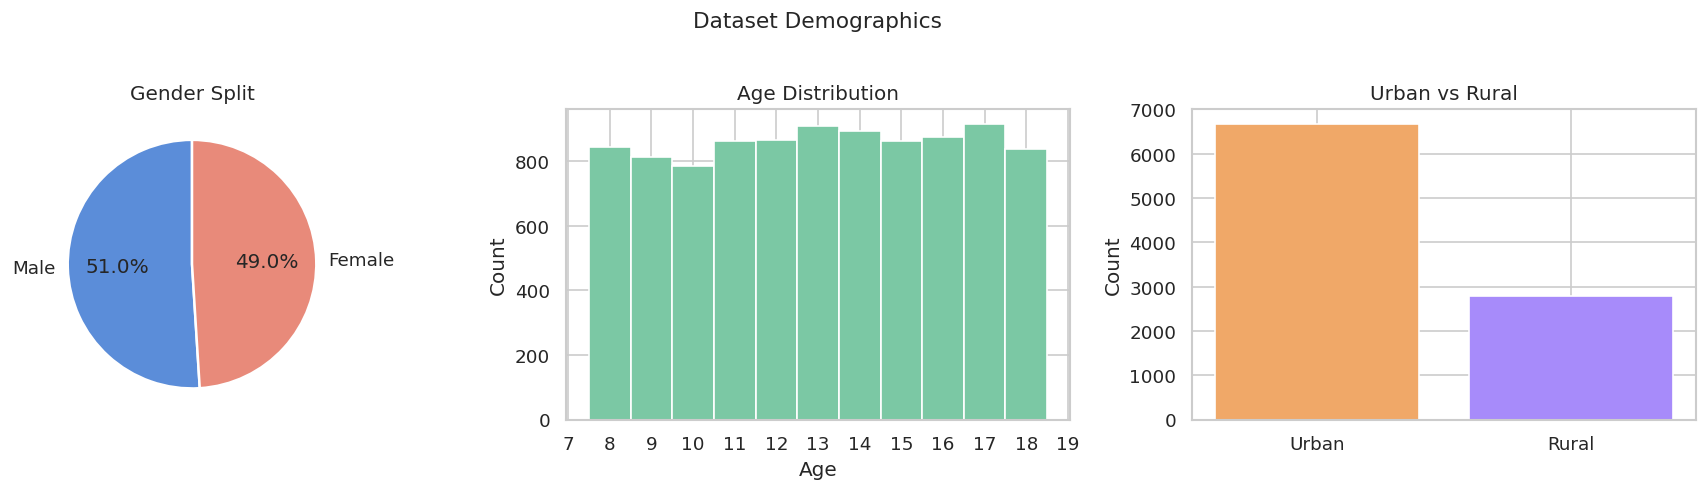

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gender split
gender_counts = df["Gender"].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#5b8dd9", "#e88a7a"], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[0].set_title("Gender Split")

# Age distribution
axes[1].hist(df["Age"], bins=range(8, 20), color="#7bc8a4", edgecolor="white", align="left")
axes[1].set_title("Age Distribution")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Urban vs Rural
location_counts = df["Urban_or_Rural"].value_counts()
axes[2].bar(location_counts.index, location_counts.values,
            color=["#f0a868", "#a78bfa"], edgecolor="white")
axes[2].set_title("Urban vs Rural")
axes[2].set_ylabel("Count")

plt.suptitle("Dataset Demographics", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_demographics.png", bbox_inches="tight")
plt.show()


### 3.2 Screen Time by Age — Does it go up as kids get older?

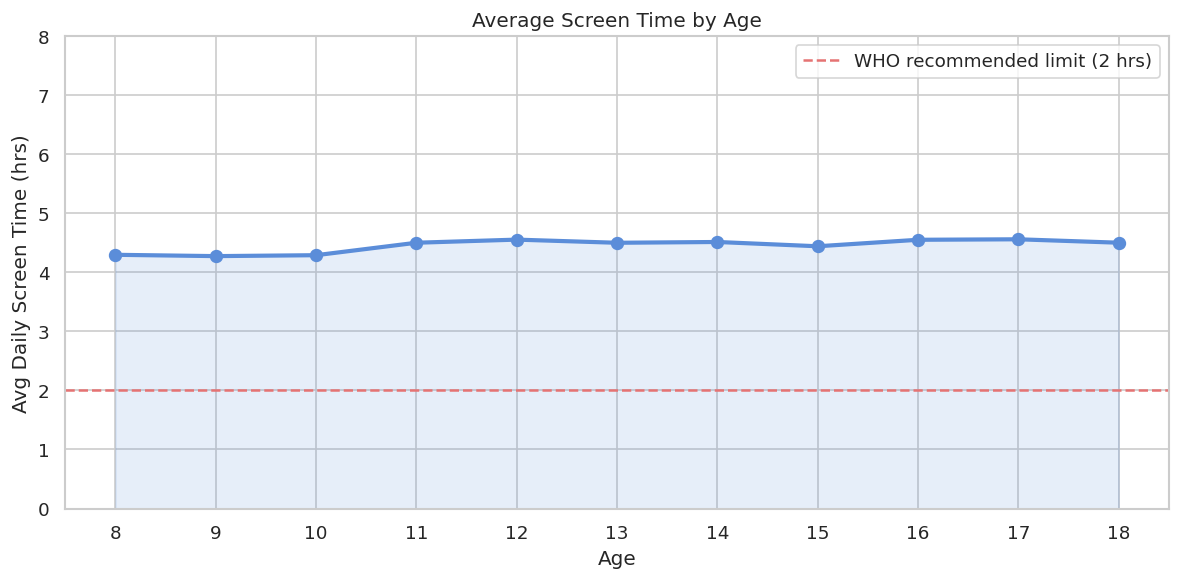

In [14]:
age_screen = df.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(age_screen["Age"], age_screen["Avg_Daily_Screen_Time_hr"],
        marker="o", linewidth=2.5, color="#5b8dd9", markersize=7)
ax.fill_between(age_screen["Age"], age_screen["Avg_Daily_Screen_Time_hr"],
                alpha=0.15, color="#5b8dd9")
ax.axhline(y=2, color="#e57373", linestyle="--", linewidth=1.5, label="WHO recommended limit (2 hrs)")
ax.set_xlabel("Age")
ax.set_ylabel("Avg Daily Screen Time (hrs)")
ax.set_title("Average Screen Time by Age")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend()
ax.set_ylim(0, 8)
plt.tight_layout()
plt.savefig("fig_screen_time_by_age.png", bbox_inches="tight")
plt.show()


### 3.3 Screen Time by Device — Which device is eating the most time?

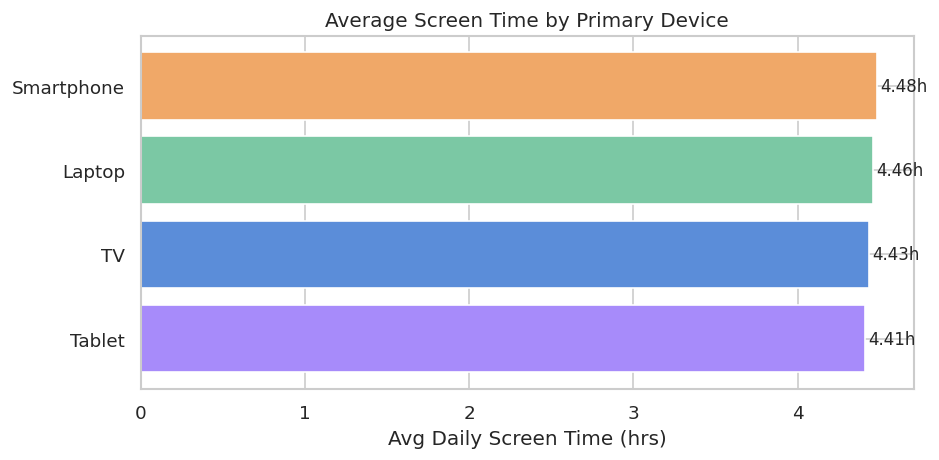

In [15]:
device_screen = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(device_screen.index, device_screen.values,
               color=["#a78bfa", "#5b8dd9", "#7bc8a4", "#f0a868"], edgecolor="white")
ax.set_xlabel("Avg Daily Screen Time (hrs)")
ax.set_title("Average Screen Time by Primary Device")
for bar, val in zip(bars, device_screen.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}h", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig_device_screen_time.png", bbox_inches="tight")
plt.show()


### 3.4 Urban vs Rural — Is location a factor?

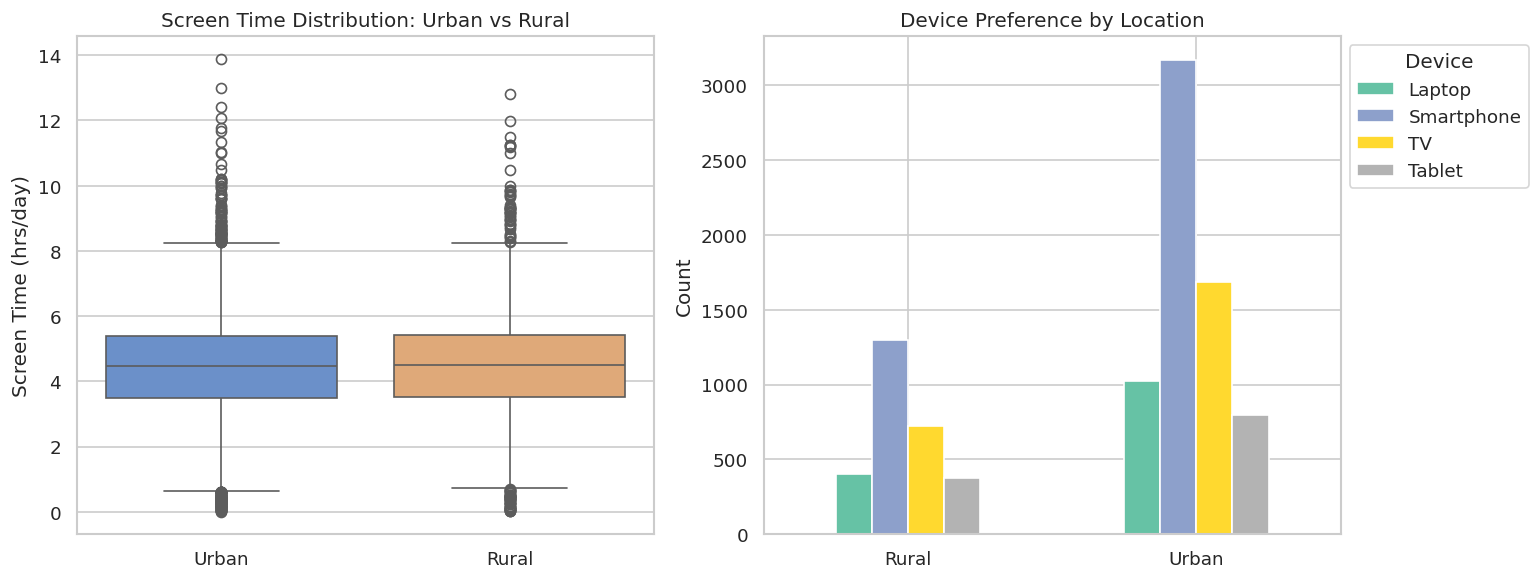

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# screen time by location
sns.boxplot(data=df, x="Urban_or_Rural", y="Avg_Daily_Screen_Time_hr",
            palette={"Urban": "#5b8dd9", "Rural": "#f0a868"}, ax=axes[0])
axes[0].set_title("Screen Time Distribution: Urban vs Rural")
axes[0].set_xlabel("")
axes[0].set_ylabel("Screen Time (hrs/day)")

# device preference by location
device_location = df.groupby(["Urban_or_Rural", "Primary_Device"]).size().unstack(fill_value=0)
device_location.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_title("Device Preference by Location")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Device", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("fig_urban_rural.png", bbox_inches="tight")
plt.show()


### 3.5 Educational vs Recreational — Are screens being used productively?

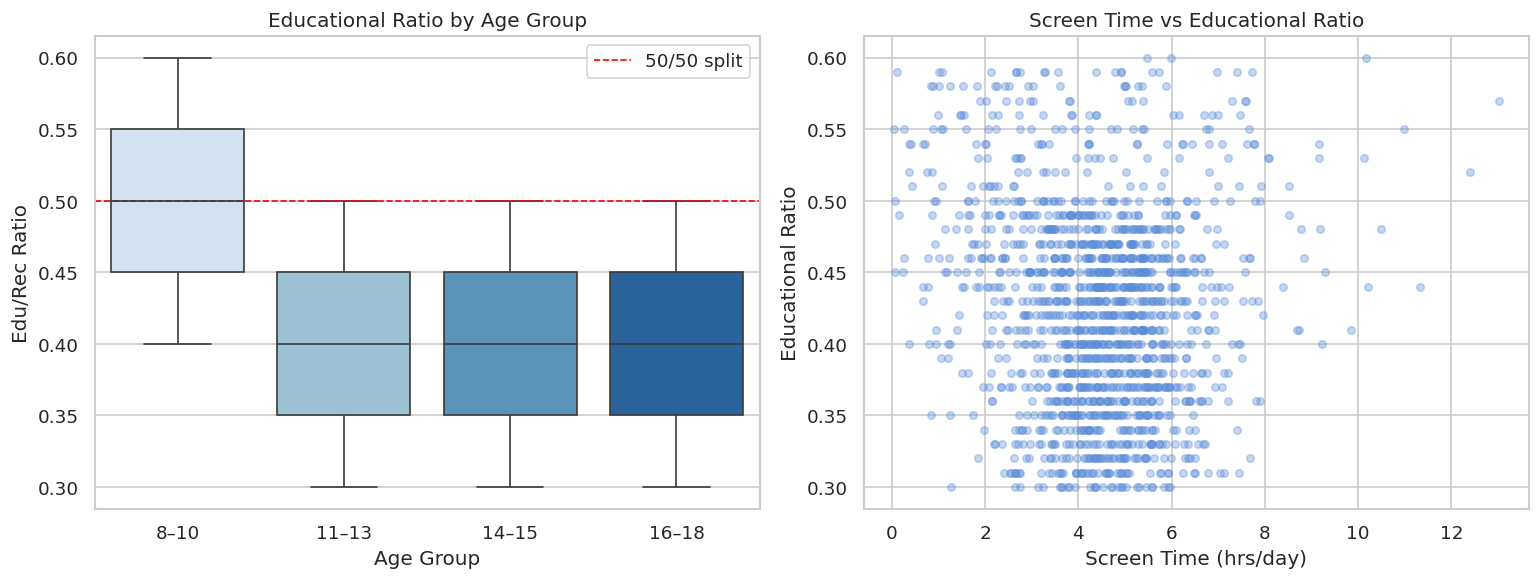

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ratio distribution by age group
df["age_group"] = pd.cut(df["Age"], bins=[7, 10, 13, 15, 18],
                          labels=["8–10", "11–13", "14–15", "16–18"])
sns.boxplot(data=df, x="age_group", y="Educational_to_Recreational_Ratio",
            palette="Blues", ax=axes[0])
axes[0].set_title("Educational Ratio by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Edu/Rec Ratio")
axes[0].axhline(0.5, color="red", linestyle="--", linewidth=1, label="50/50 split")
axes[0].legend()

# ratio vs screen time scatter
sample = df.sample(min(1500, len(df)), random_state=42)
axes[1].scatter(sample["Avg_Daily_Screen_Time_hr"],
                sample["Educational_to_Recreational_Ratio"],
                alpha=0.35, color="#5b8dd9", s=20)
axes[1].set_title("Screen Time vs Educational Ratio")
axes[1].set_xlabel("Screen Time (hrs/day)")
axes[1].set_ylabel("Educational Ratio")

plt.tight_layout()
plt.savefig("fig_edu_ratio.png", bbox_inches="tight")
plt.show()


### 3.6 Health Impacts — What's actually being reported?

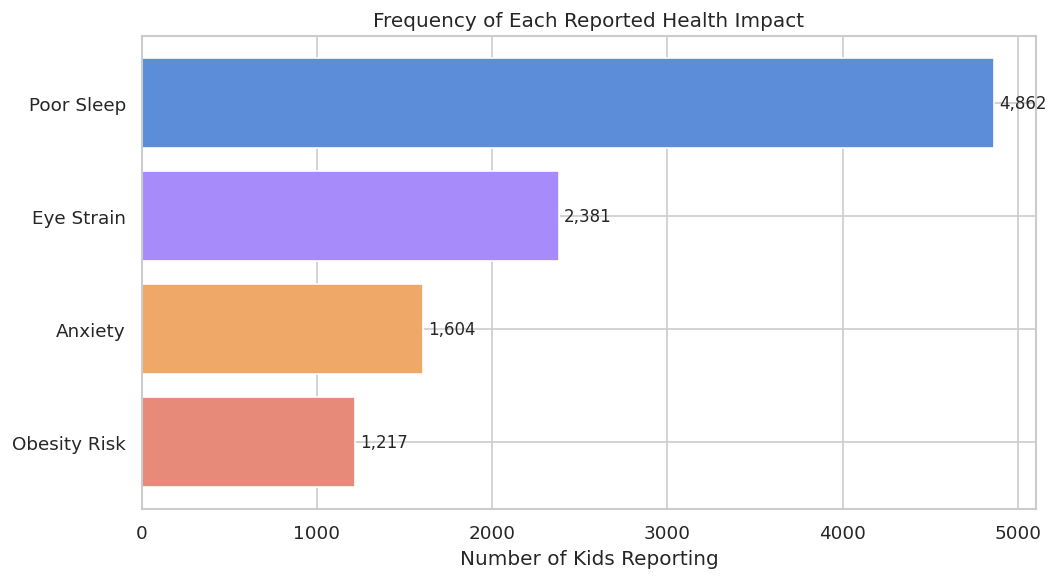

In [18]:
# Health_Impacts has multi-label values like "Poor Sleep, Anxiety"
# We need to split and count each condition individually

all_impacts = []
for entry in df["Health_Impacts"]:
    for impact in entry.split(","):
        clean = impact.strip()
        if clean != "None Reported":
            all_impacts.append(clean)

impact_counts = pd.Series(Counter(all_impacts)).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e88a7a", "#f0a868", "#a78bfa", "#5b8dd9"]
ax.barh(impact_counts.index, impact_counts.values, color=colors, edgecolor="white")
ax.set_title("Frequency of Each Reported Health Impact")
ax.set_xlabel("Number of Kids Reporting")
for i, (val, label) in enumerate(zip(impact_counts.values, impact_counts.index)):
    ax.text(val + 30, i, f"{val:,}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig_health_impacts.png", bbox_inches="tight")
plt.show()


In [19]:
# Does exceeding screen time limit correlate with more health impacts?
df["has_health_impact"] = df["Health_Impacts"] != "None Reported"
df["impact_count"] = df["Health_Impacts"].apply(
    lambda x: 0 if x == "None Reported" else len(x.split(","))
)

print("Average number of health impacts:")
print(df.groupby("Exceeded_Recommended_Limit")["impact_count"].mean().round(2))
print()
print("% who reported at least one impact:")
print((df.groupby("Exceeded_Recommended_Limit")["has_health_impact"].mean() * 100).round(1))


Average number of health impacts:
Exceeded_Recommended_Limit
False    0.00
True     1.21
Name: impact_count, dtype: float64

% who reported at least one impact:
Exceeded_Recommended_Limit
False     0.0
True     78.2
Name: has_health_impact, dtype: float64


### 3.7 Gender Differences — Screentime & Health

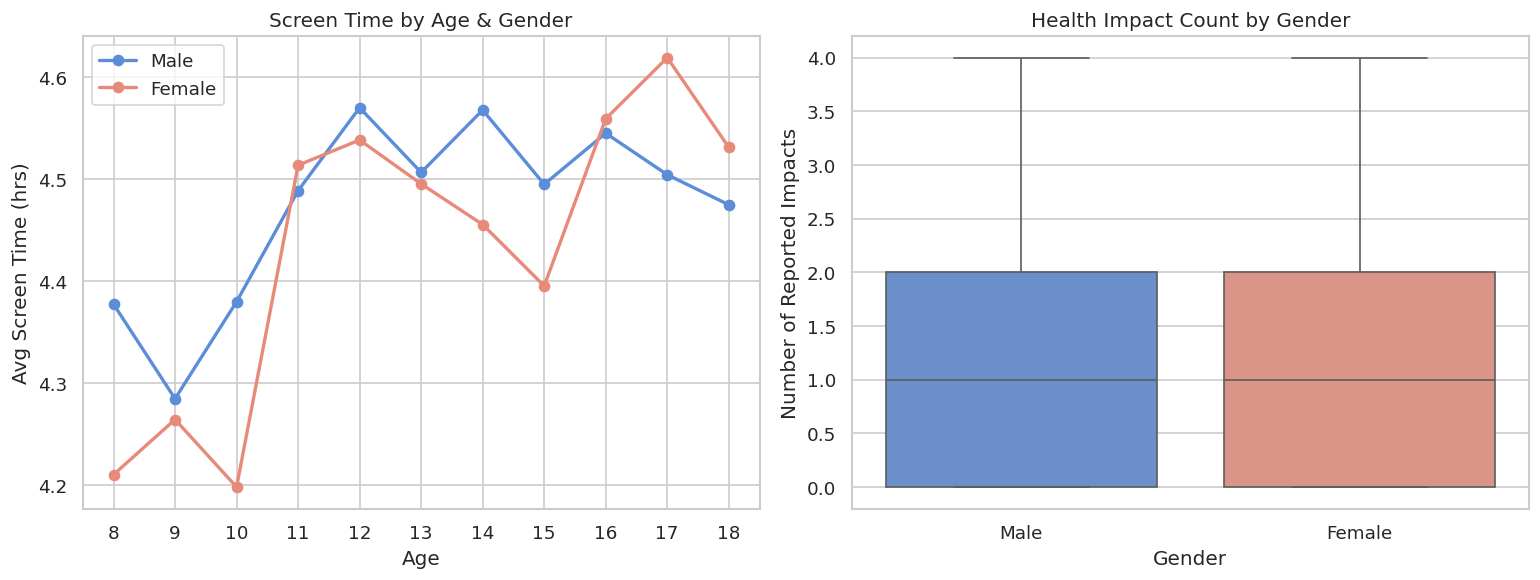

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# screen time by gender across ages
gender_age = df.groupby(["Age", "Gender"])["Avg_Daily_Screen_Time_hr"].mean().unstack()
for gender, color in zip(["Male", "Female"], ["#5b8dd9", "#e88a7a"]):
    axes[0].plot(gender_age.index, gender_age[gender],
                 marker="o", label=gender, color=color, linewidth=2)
axes[0].set_title("Screen Time by Age & Gender")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Avg Screen Time (hrs)")
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# health impact count by gender
sns.boxplot(data=df, x="Gender", y="impact_count",
            palette={"Male": "#5b8dd9", "Female": "#e88a7a"}, ax=axes[1])
axes[1].set_title("Health Impact Count by Gender")
axes[1].set_ylabel("Number of Reported Impacts")

plt.tight_layout()
plt.savefig("fig_gender_analysis.png", bbox_inches="tight")
plt.show()


---
## 4. Key Insights

These are the observations that actually stood out — not just summary statistics.


In [21]:
# Insight 1: How bad is the screen time problem really?
exceeded_pct = df["Exceeded_Recommended_Limit"].mean() * 100
print(f"[Insight 1] {exceeded_pct:.1f}% of kids exceeded the recommended screen time limit.")
print()

# Insight 2: Screen time does increase with age — but less dramatically than expected
age_range_diff = df.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean()
print(f"[Insight 2] Screen time range: {age_range_diff.min():.2f} hrs (age {age_range_diff.idxmin()}) "
      f"to {age_range_diff.max():.2f} hrs (age {age_range_diff.idxmax()})")
print()

# Insight 3: No strong device-based difference
print("[Insight 3] Average screen time by device:")
print(df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().round(2))
print()

# Insight 4: Urban kids have slightly higher screen time
print("[Insight 4] Average screen time - Urban vs Rural:")
print(df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean().round(2))
print()

# Insight 5: Educational ratio is low across the board
print(f"[Insight 5] Median educational ratio: {df['Educational_to_Recreational_Ratio'].median():.2f}")
print("This means even in the best case, less than half of screen time is educational.")
print()

# Insight 6: Kids who exceed limits report more health impacts
exceeded_impact = df.groupby("Exceeded_Recommended_Limit")["impact_count"].mean()
print("[Insight 6] Average health impacts:")
print(exceeded_impact.round(2))


[Insight 1] 87.5% of kids exceeded the recommended screen time limit.

[Insight 2] Screen time range: 4.27 hrs (age 9) to 4.56 hrs (age 17)

[Insight 3] Average screen time by device:
Primary_Device
Laptop        4.46
Smartphone    4.48
TV            4.43
Tablet        4.41
Name: Avg_Daily_Screen_Time_hr, dtype: float64

[Insight 4] Average screen time - Urban vs Rural:
Urban_or_Rural
Rural    4.47
Urban    4.45
Name: Avg_Daily_Screen_Time_hr, dtype: float64

[Insight 5] Median educational ratio: 0.42
This means even in the best case, less than half of screen time is educational.

[Insight 6] Average health impacts:
Exceeded_Recommended_Limit
False    0.00
True     1.21
Name: impact_count, dtype: float64


---
## 5. Conclusion

This project started with a straightforward dataset but turned up some patterns worth paying attention to.

**What the data actually says:**

- Screen time limits are being exceeded by a large majority of kids — this isn't a fringe issue. It's the norm in this dataset.
- The educational-to-recreational ratio is consistently low across all age groups, which means most screen time isn't serving any learning purpose.
- Kids who exceed the recommended limit do report more health impacts on average, particularly poor sleep and eye strain. The association is there, though this data can't prove causation.
- Urban kids are on screens slightly more than rural kids, but the gap isn't dramatic — it's not like rural India is immune to this.
- Surprisingly, device type barely matters. Whether it's a phone, tablet, laptop, or TV — the average screen time is nearly identical across devices. The problem isn't the device; it's the behavior.

**What this project taught me:**

- Missing values aren't always errors — sometimes they carry meaning (like `Health_Impacts` being blank means no impact was reported).
- Zero values can be more suspicious than extreme values (a kid with 0 screen time but marked as "exceeded limit" is a data problem, not an outlier).
- Multi-label columns need to be unpacked before you can count anything meaningful.

**If I were to extend this project:**

- Bring in time-series data to track trends over years
- Try clustering kids by usage patterns (heavy educational vs heavy recreational vs minimal use)
- Build a simple model to predict health impact likelihood from screen time + device + age


---
## Appendix: Cleaned Data Export


In [22]:
# Save cleaned dataset
export_cols = [c for c in df.columns if c not in ["screen_time_flag", "age_group", "has_health_impact", "impact_count"]]
df[export_cols].to_csv("Indian_Kids_Screen_Time_Cleaned.csv", index=False)
print("Cleaned file saved as: Indian_Kids_Screen_Time_Cleaned.csv")
print("Final shape:", df[export_cols].shape)


Cleaned file saved as: Indian_Kids_Screen_Time_Cleaned.csv
Final shape: (9474, 8)
